In [4]:
import base64
import gzip
import json
import pickle
import pyrender
import numpy as np
import random
import secrets
import trimesh
import voxeloo
import zlib
import os
import json

from PIL import Image
from dataclasses import dataclass
from functools import cache
from matplotlib import pyplot as plt
from scipy.ndimage import (
    distance_transform_edt as edt,
    gaussian_filter as blur, 
)
from tqdm.notebook import tqdm
from typing import Any, List, Optional, Dict, Tuple
from scipy import ndimage
from itertools import chain
from multiprocessing import Pool
import base64
from collections import defaultdict

# Info

This is a script to fill in holes in an existing plot_map.json

After running this, run plots_merge again to generate a new json

## Config

In [5]:
ROOT_DIR = "/home/brandon/ill/pydata"
PLOT_MAP = "/home/brandon/ill/zones/src/shared/asset_defs/gen/plot_map.json"

PADDING_MASK_ID = 5664385117739341

# plot size dimension (1d)
# 16 = 16x16
spacing = 24
CHUNK_PADDING = spacing * 3

chunk = (0, -1)
chunk_size = 2048
pos_offset = (chunk[0] * chunk_size - CHUNK_PADDING, chunk[1] * chunk_size - CHUNK_PADDING)
padding_dim = (chunk_size + CHUNK_PADDING * 2, chunk_size + CHUNK_PADDING * 2)

In [ ]:
def chunk_name(chunk):
    return "_".join(map(str, chunk))

#### Generation Order

### Visualization Routines

In [6]:
def heatmap_to_image(heat):
    return Image.fromarray(np.uint8(heat * 255) , "L")

## Load Data

In [9]:
# Load plot map
plot_index = voxeloo.runs.Index_U64()
previous_plot_blobs = {}
if os.path.exists(PLOT_MAP):
    with open(PLOT_MAP, "r") as f:
        previous_plot_blobs = json.load(f)
local_plot_path = f"{ROOT_DIR}/alpha_world/plots/plot_map_{chunk_name(chunk)}.txt"
# Prefer plot_map_*.txt over plot_map.json
if os.path.exists(local_plot_path):
    with open(local_plot_path, "r") as f:
        plot_index.loads(base64.decodebytes(f.read().encode()))
else:
    blob = previous_plot_blobs.get(chunk_name(chunk))
    if blob is not None:
        plot_index.loads(base64.decodebytes(blob.encode()))
    else:
        raise Exception("No plot map found")    

In [10]:
def load_previous_plots(chunk):
    prev_chunks = []
    for prev_chunk in generation_order:
        if prev_chunk == chunk:
            break
        prev_chunks.append(prev_chunk)
    dependent_chunks = surrounding_chunks(chunk)
    prev_chunk_to_index = {}
    for i, prev_chunk in enumerate(prev_chunks):
        prev_chunk_to_index[prev_chunk] = i
    previous_plots = []
    for chunk_index, chunk in enumerate(dependent_chunks):
        if chunk not in prev_chunk_to_index:
            continue
        order_index = prev_chunk_to_index[chunk]
        plot_index = voxeloo.runs.Index_U64()
        local_plot_path = f"{ROOT_DIR}/alpha_world/plots/plot_map_{chunk_name(chunk)}.txt"
        if os.path.exists(local_plot_path):
            with open(local_plot_path, "r") as f:
                plot_index.loads(base64.decodebytes(f.read().encode()))
        else:
            blob = previous_plot_blobs[chunk_name(chunk)]
            plot_index.loads(base64.decodebytes(blob.encode()))
        previous_plots.append({"chunk_index": chunk_index, "index": plot_index, "order": order_index})
    return previous_plots

def load_padding(prev_plots):
    arr = np.ndarray(padding_dim, dtype=np.uint64)
    arr.fill(PADDING_MASK_ID)
    span_data = {
        0: ((CHUNK_PADDING*2, CHUNK_PADDING*2), (0,0), (padding_dim[0]-CHUNK_PADDING*2, padding_dim[1]-CHUNK_PADDING*2)),
        1: ((padding_dim[0], CHUNK_PADDING*2), (0,0), (0, padding_dim[1]-CHUNK_PADDING*2)),
        2: ((CHUNK_PADDING*2, CHUNK_PADDING*2), (padding_dim[0]-CHUNK_PADDING*2,0), (0, padding_dim[1]-CHUNK_PADDING*2)),
        3: ((CHUNK_PADDING*2, padding_dim[1]), (0,0), (padding_dim[0]-CHUNK_PADDING*2, 0)),
        5: ((CHUNK_PADDING*2, padding_dim[1]), (padding_dim[0]-CHUNK_PADDING*2,0), (0, 0)),
        6: ((CHUNK_PADDING*2, CHUNK_PADDING*2), (0, padding_dim[1]-CHUNK_PADDING*2), (padding_dim[0]-CHUNK_PADDING*2, 0)),
        7: ((padding_dim[0], CHUNK_PADDING*2), (0, padding_dim[1]-CHUNK_PADDING*2), (0, 0)),
        8: ((CHUNK_PADDING*2, CHUNK_PADDING*2), (padding_dim[0]-CHUNK_PADDING*2, padding_dim[1]-CHUNK_PADDING*2), (0, 0)),
    }
    # load in order of generation, so any overlaps are replaced with the newest data
    sorted_prev = sorted(prev_plots, key=lambda x: x["order"])
    for prev_plot in sorted_prev:
        [span, local_offset, index_offset] = span_data[prev_plot["chunk_index"]]
        index = prev_plot["index"]
        if index is None:
            continue
        for i in range(span[0]):
            for j in range(span[1]):
                index_idx = (i + index_offset[0]) * padding_dim[1] + (j + index_offset[1])
                local_idx = (i+local_offset[0], j+local_offset[1])
                existing = arr[local_idx[0]][local_idx[1]]
                new_val = index.get(index_idx)
                if existing != PADDING_MASK_ID and existing != new_val:
                    print(f"inconsistency at {index}: ({i}, {j}): {existing} != {new_val}")
                arr[local_idx[0]][local_idx[1]] = new_val
    return arr

def vis_padding_border(vis):
    dim = vis.shape
    for x in range(CHUNK_PADDING, dim[0]-CHUNK_PADDING-1):
        vis[x][CHUNK_PADDING] = [255, 0, 0]
        vis[x][dim[1]-CHUNK_PADDING-1] = [255, 0, 0]
    for y in range(CHUNK_PADDING, dim[0]-CHUNK_PADDING-1):
        vis[CHUNK_PADDING][y] = [255, 0, 0]
        vis[dim[0]-CHUNK_PADDING-1][y] = [255, 0, 0]
    return vis



In [11]:
regions = load_padded_region(chunk)
existing_plots = load_padding(load_previous_plots(chunk))

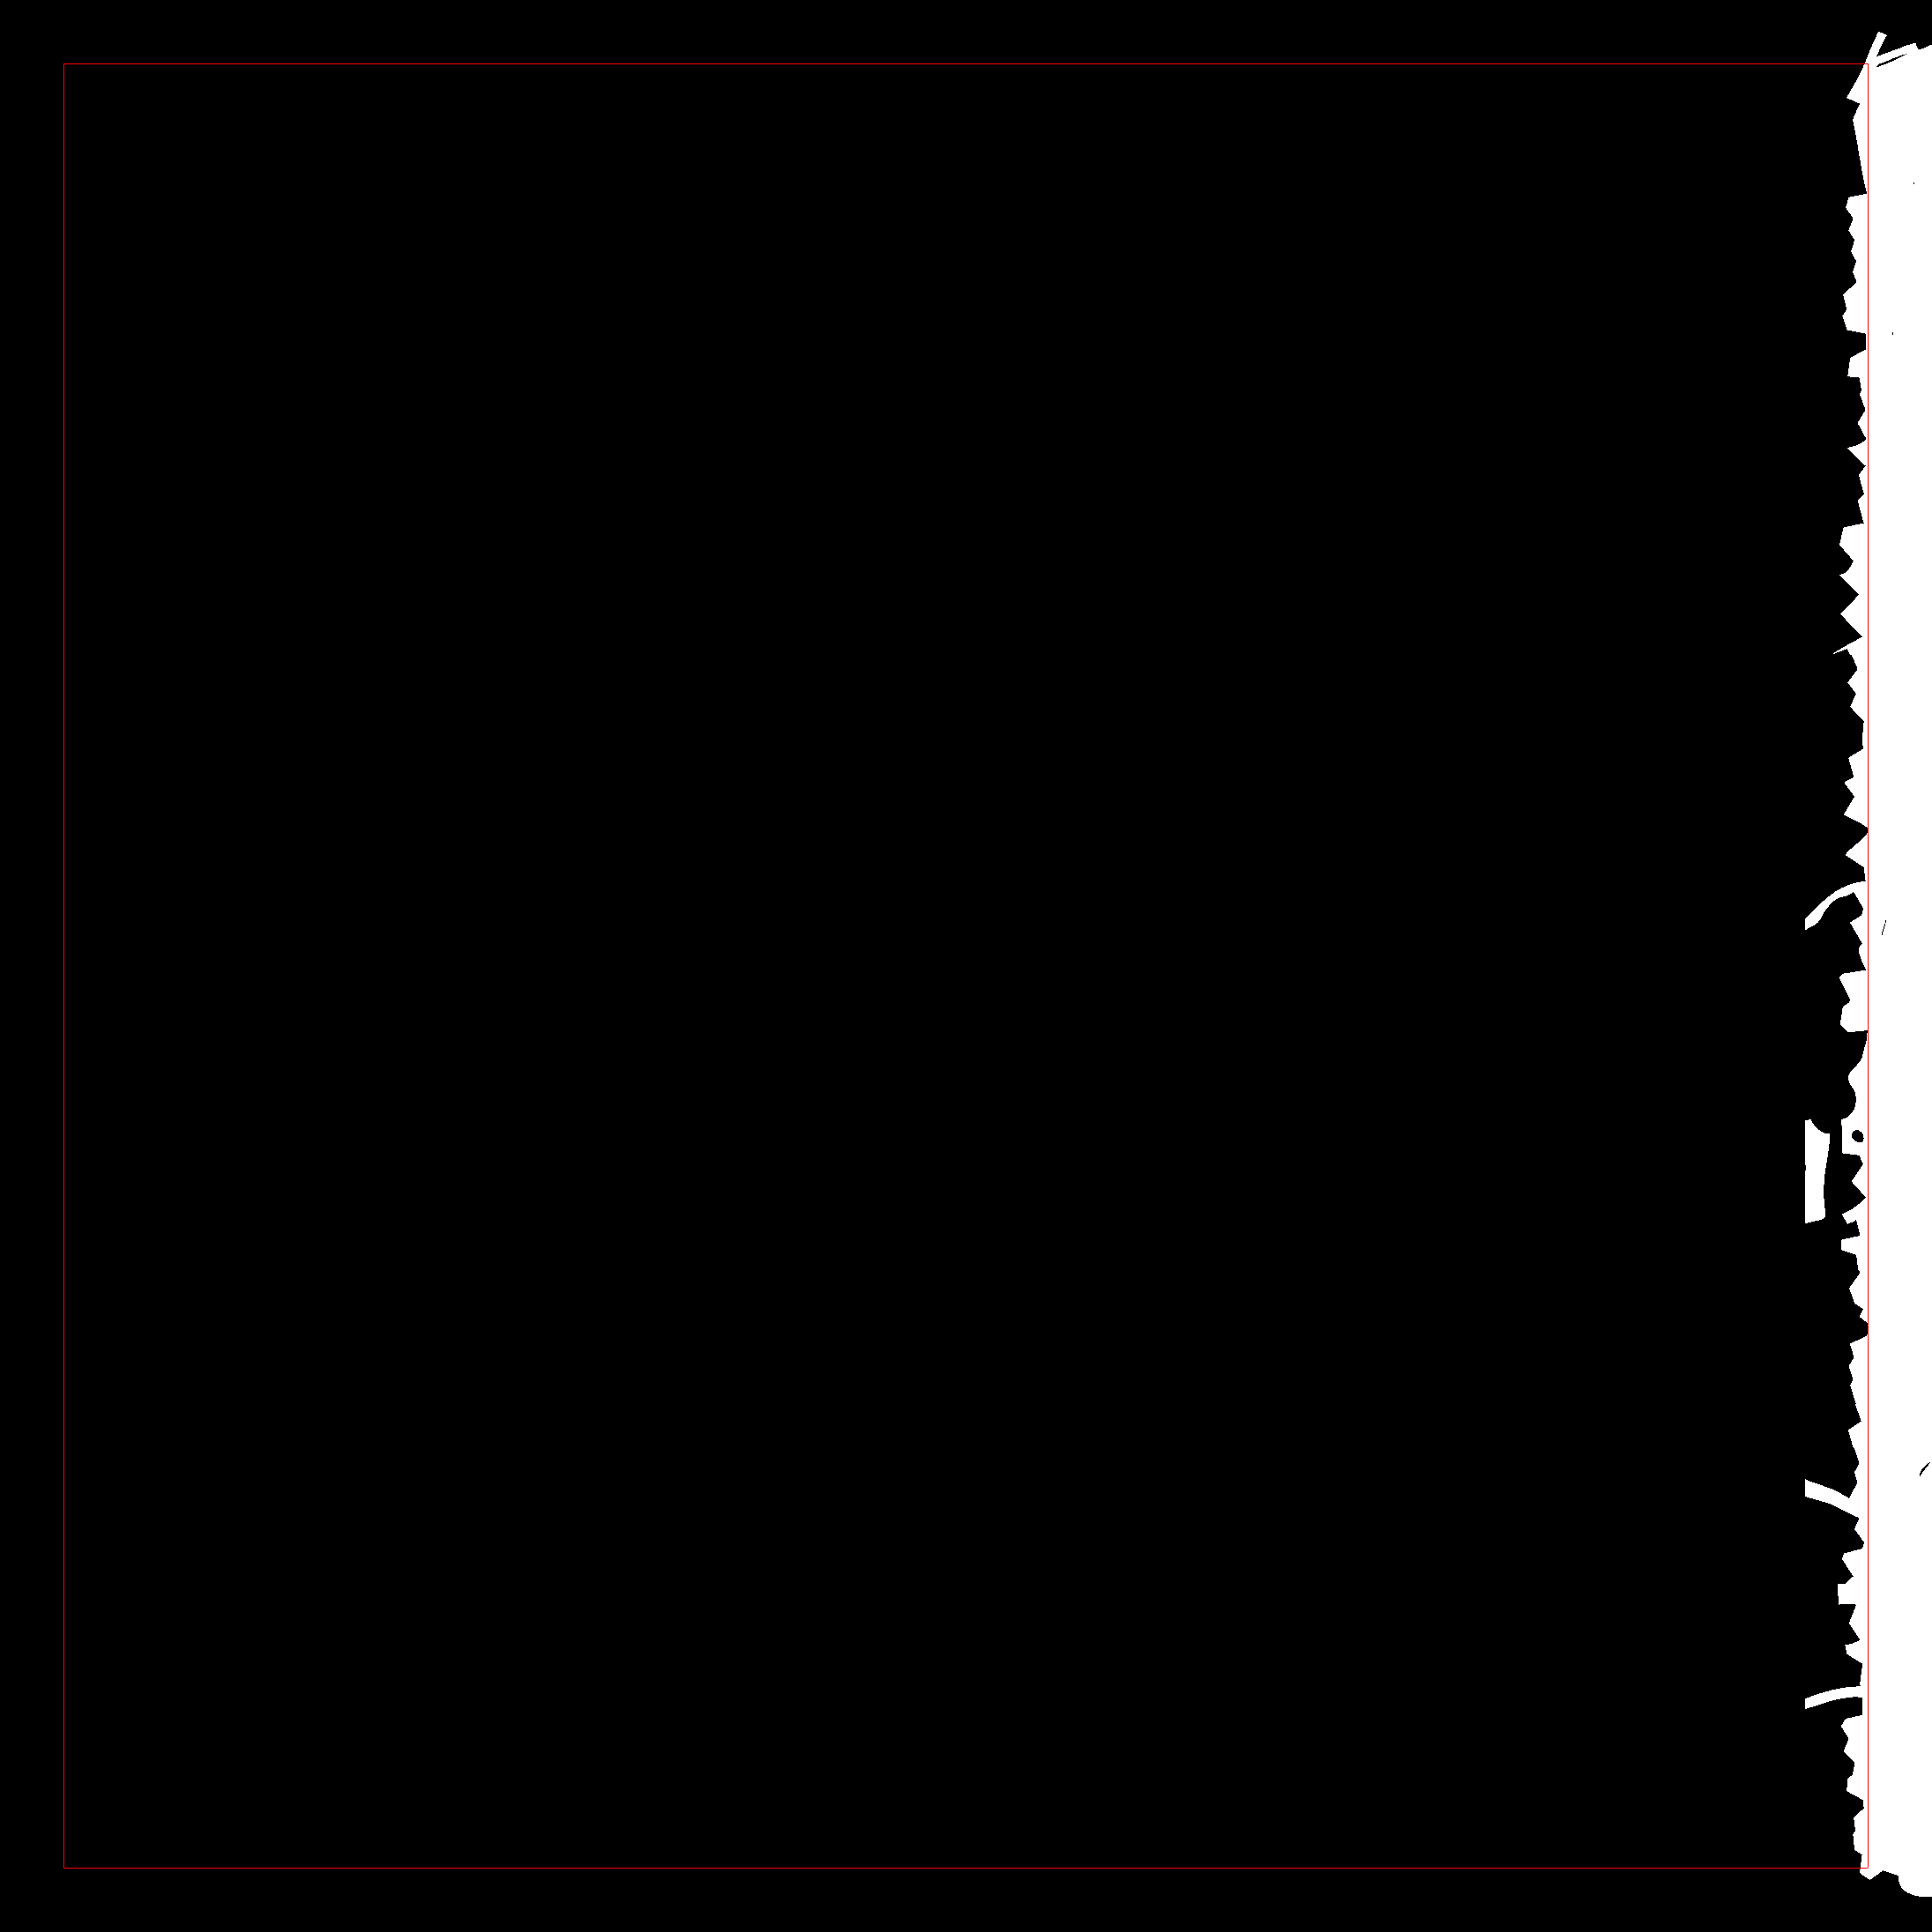

In [12]:
mask = np.not_equal(existing_plots, PADDING_MASK_ID)
gray_palette = np.ndarray([2, 3], dtype=np.uint8)
gray_palette[0] = [0, 0, 0]
gray_palette[1] = [255, 255, 255]
vis = gray_palette[mask.astype(np.uint8)]

Image.fromarray(vis_padding_border(vis))

### All plots fully within the padding region are replaced with a mask

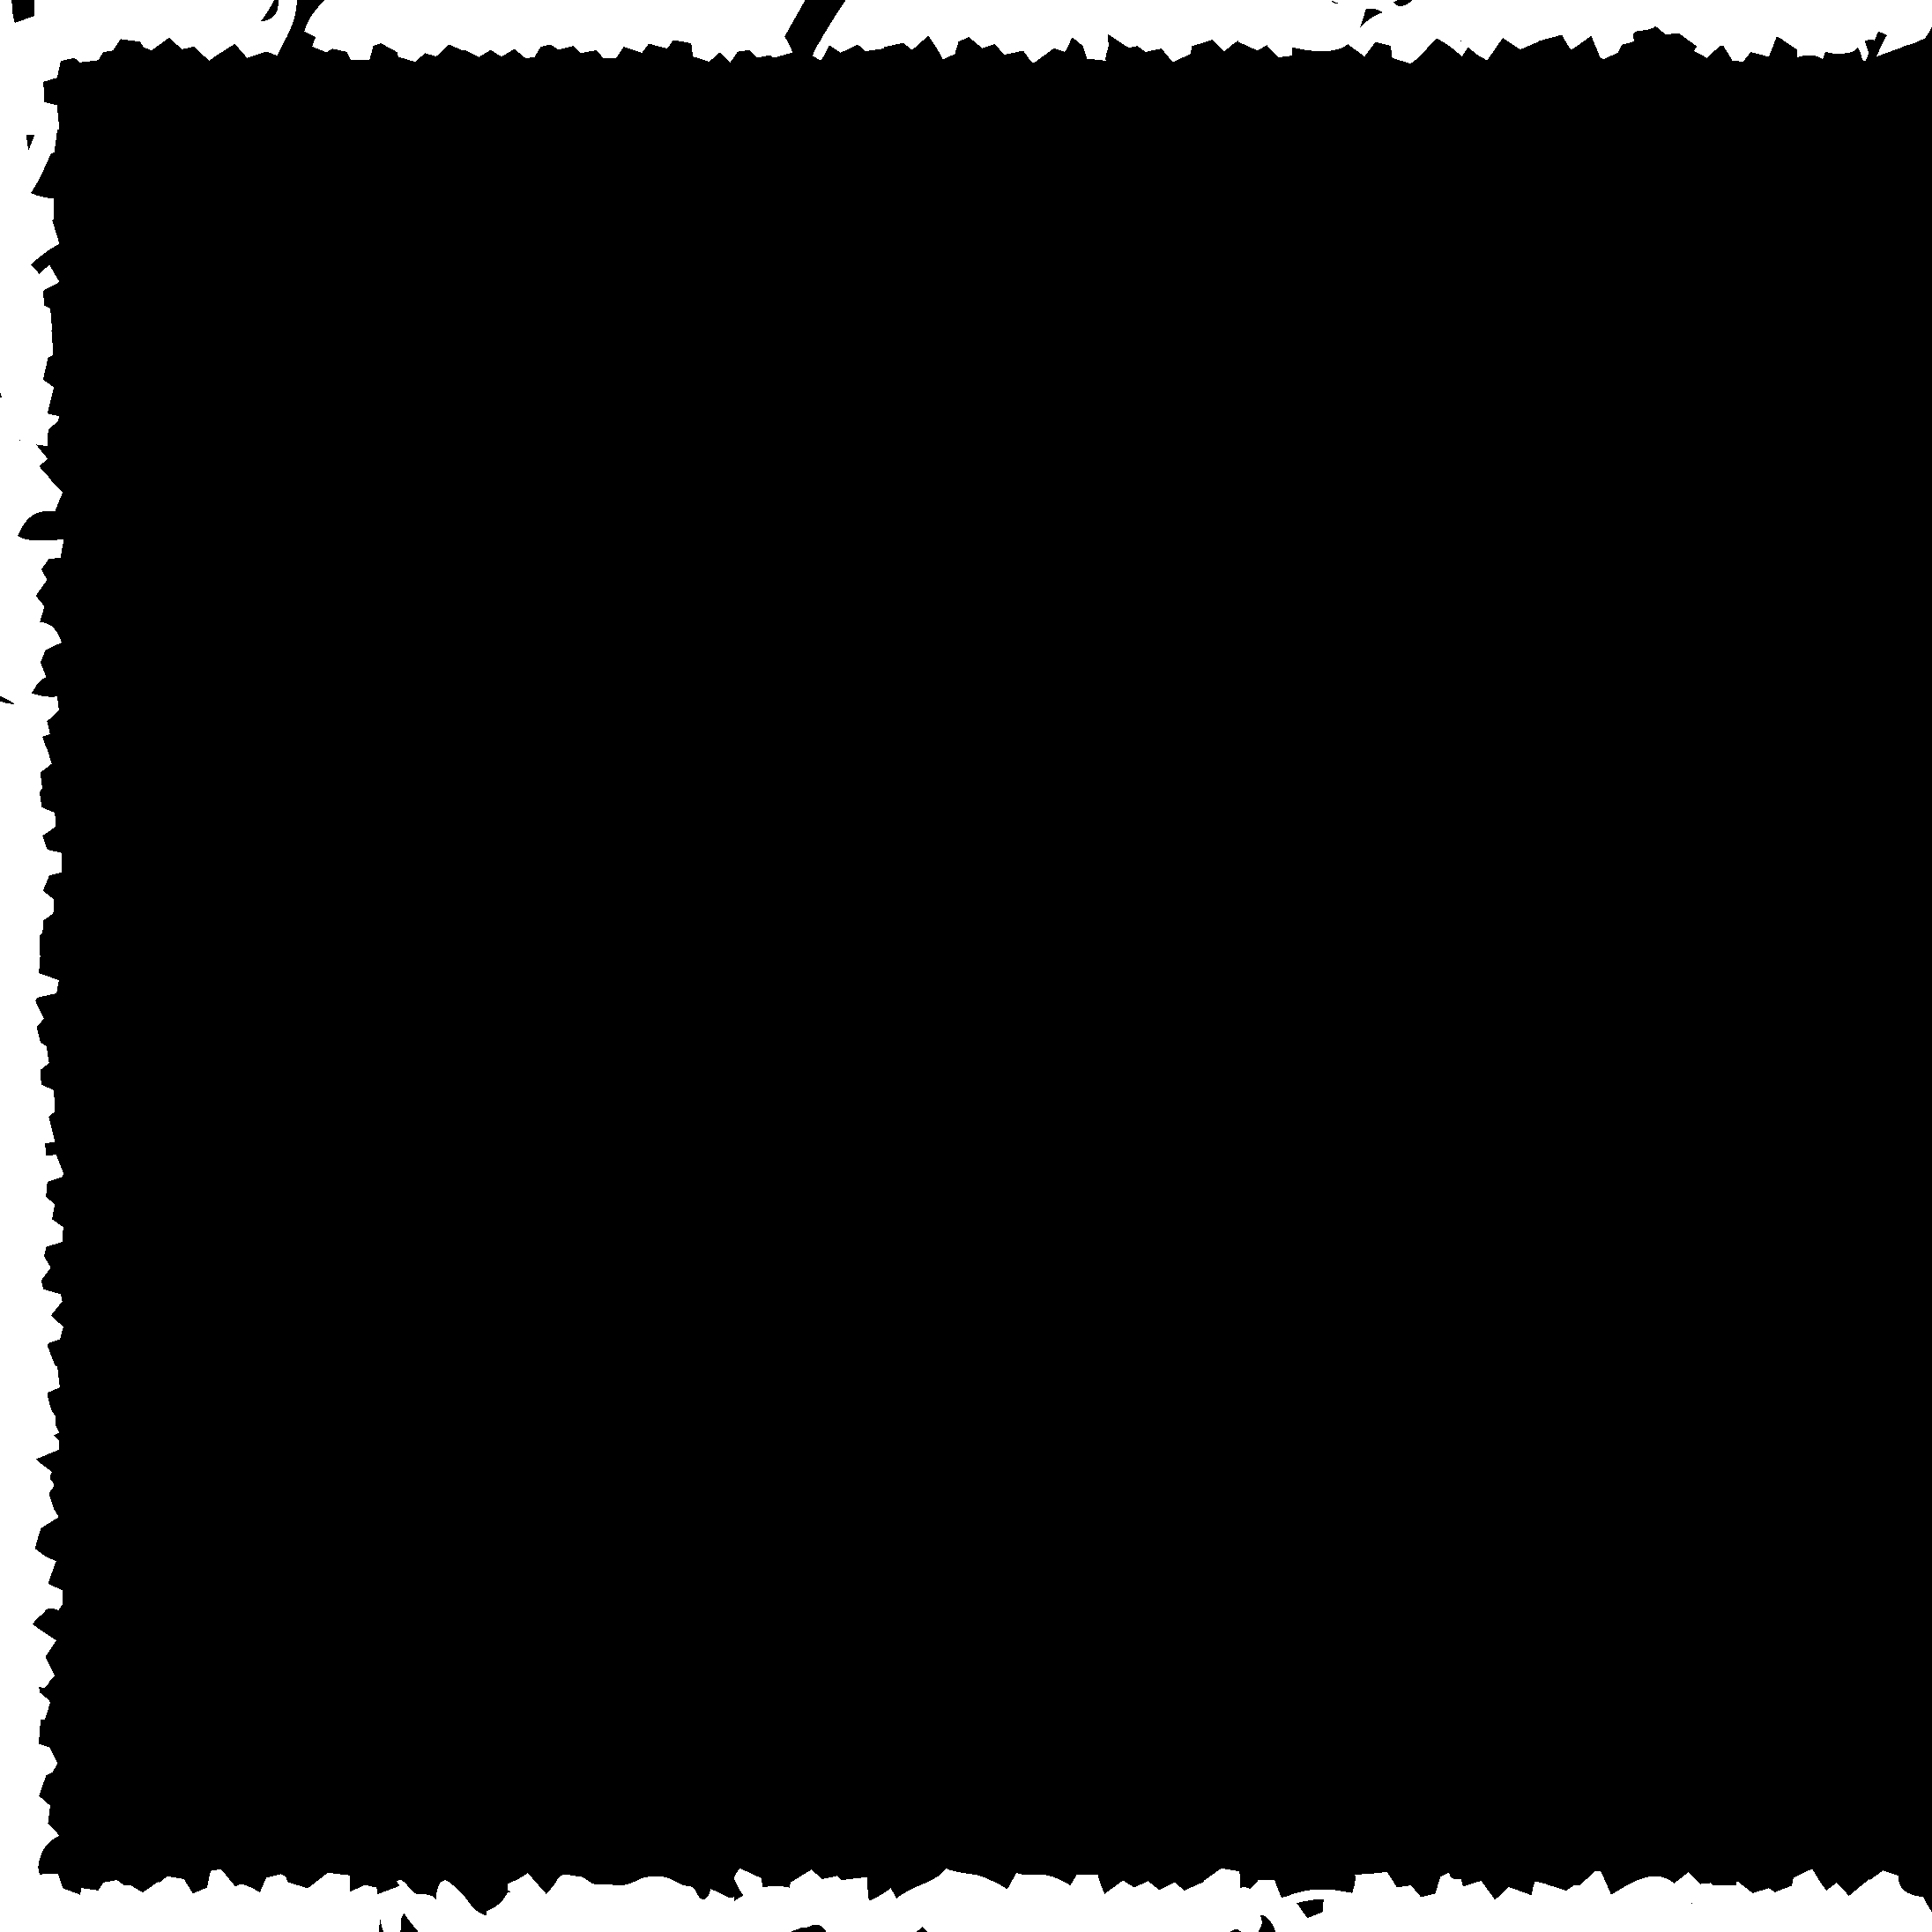

In [ ]:
# Find all plots on the inner border of the generated plots, and store in a set
border_points = set()
for x in range(CHUNK_PADDING, map_dim[0]-CHUNK_PADDING-1):
    border_points.add(tiles[x][CHUNK_PADDING])
    border_points.add(tiles[x][map_dim[1]-CHUNK_PADDING-1])
for y in range(CHUNK_PADDING, map_dim[1]-CHUNK_PADDING-1):
    border_points.add(tiles[CHUNK_PADDING][y])
    border_points.add(tiles[map_dim[0]-CHUNK_PADDING-1][y])

# Go over all padding points and remove any that were not on the border
for x in range(map_dim[0]):
    for y in range(CHUNK_PADDING):
        if tiles[x][y] in border_points:
            continue
        tiles[x][y] = -1
    for y in range(map_dim[0] - CHUNK_PADDING-1, map_dim[0]):
        if tiles[x][y] in border_points:
            continue
        tiles[x][y] = -1
for x in range(CHUNK_PADDING):
    for y in range(map_dim[1]):
        if tiles[x][y] in border_points:
            continue
        tiles[x][y] = -1
for x in range(map_dim[1] - CHUNK_PADDING-1, map_dim[1]):
    for y in range(map_dim[1]):
        if tiles[x][y] in border_points:
            continue
        tiles[x][y] = -1

# Check to see we have no plots on the border
for x in range(map_dim[0]):
    if tiles[x][0] > 0:
        print(f"Warning: Plot {tiles[x][0]} on border at ({x}, 0)")
    if tiles[x][-1] > 0:
        print(f"Warning: Plot {tiles[x][-1]} on border at ({x}, {map_dim[1]-1})")
for y in range(map_dim[1]):
    if tiles[0][y] > 0:
        print(f"Warning: Plot {tiles[0][y]} on border at (0, {y})")
    if tiles[-1][y] > 0:
        print(f"Warning: Plot {tiles[-1][y]} on border at ({map_dim[1]-1}, {y})")

display(Image.fromarray(np.equal(tiles, -1).astype(np.uint8) * 255))

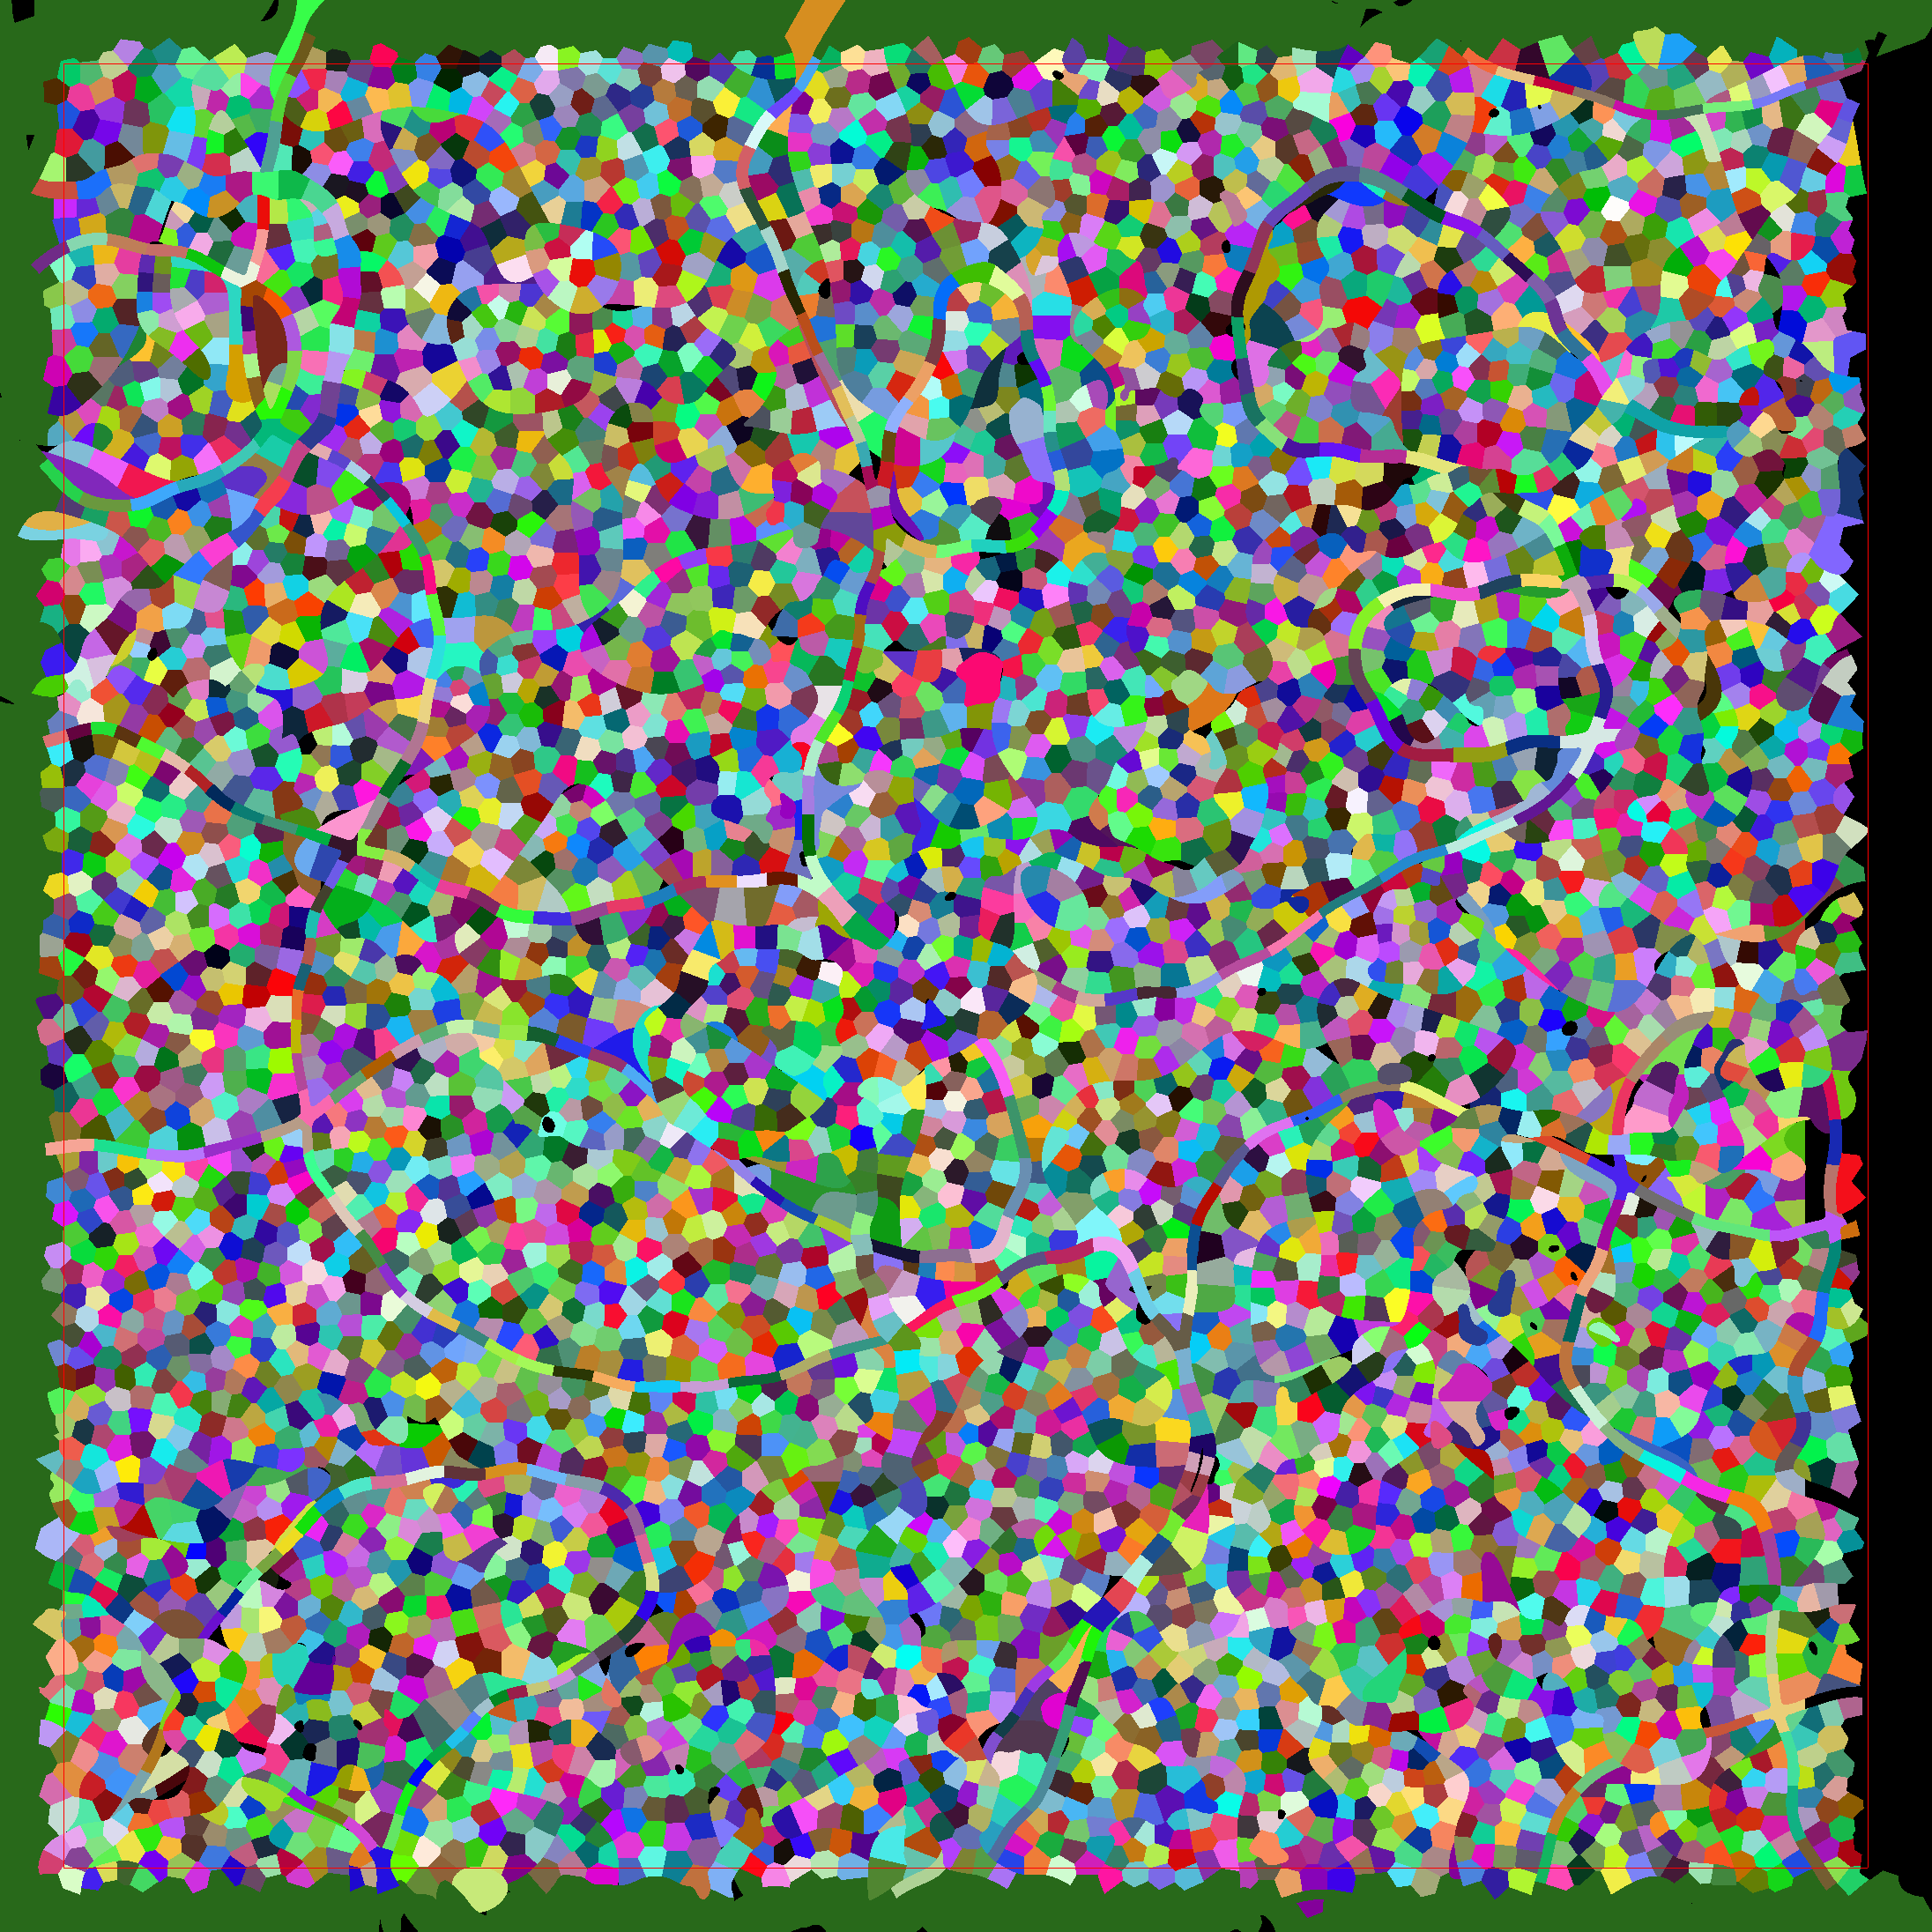

In [ ]:
display(Image.fromarray(vis_padding_border(palette[tiles])))

# Find orphaned tiles that are not in padding

In [ ]:
# For all plots that are padding and do not extend past the padding border, assign them an ID to prevent gaps.
orphan_vis = np.full(map_dim, 0)
seen = set()
def search_connected(x, y, id):
    to_explore = [(x,y)]
    res = []
    while len(to_explore) > 0:
        (x,y) = to_explore.pop()
        if (x, y) in seen:
            continue
        if x < 0 or x >= map_dim[0] or y < 0 or y >= map_dim[1]:
            continue
        if not np.equal(existing_plots[x][y], PADDING_MASK_ID):
            continue
        seen.add((x, y))
        if tiles[x][y] != id:
            continue
        res.append((x,y))
        orphan_vis[x][y] = 1
        to_explore.append((x-1, y))
        to_explore.append((x+1, y))
        to_explore.append((x, y-1))
        to_explore.append((x, y+1))
    return res

leftover_shapes = []
for x in range(map_dim[0]):
    for y in range(map_dim[1]):
        id = tiles[x][y]
        if id != 0:
            continue
        if (x, y) in seen:
            continue
        connected_shape = search_connected(x, y, 0)
        inside_padding = False
        for (x, y) in connected_shape:
            if x >= CHUNK_PADDING and x < map_dim[0] - CHUNK_PADDING and y >= CHUNK_PADDING and y < map_dim[1] - CHUNK_PADDING:
                inside_padding = True
                break
        if not inside_padding:
            continue
        if len(connected_shape) == 0:
            continue
        leftover_shapes.append(connected_shape)

print(f"Found {len(leftover_shapes)} leftover shapes")
small_shapes = []
large_shapes = []
for shapes in leftover_shapes:
    if len(shapes) < 100 :
        small_shapes.append(shapes)
        for (x,y) in shapes:
            orphan_vis[x][y] = 2
    else:
        large_shapes.append(shapes)
        for (x,y) in shapes:
            orphan_vis[x][y] = 3
print(f"{len(small_shapes)} small shapes")
print(f"{len(large_shapes)} large shapes")

Found 260 leftover shapes
208 small shapes
52 large shapes


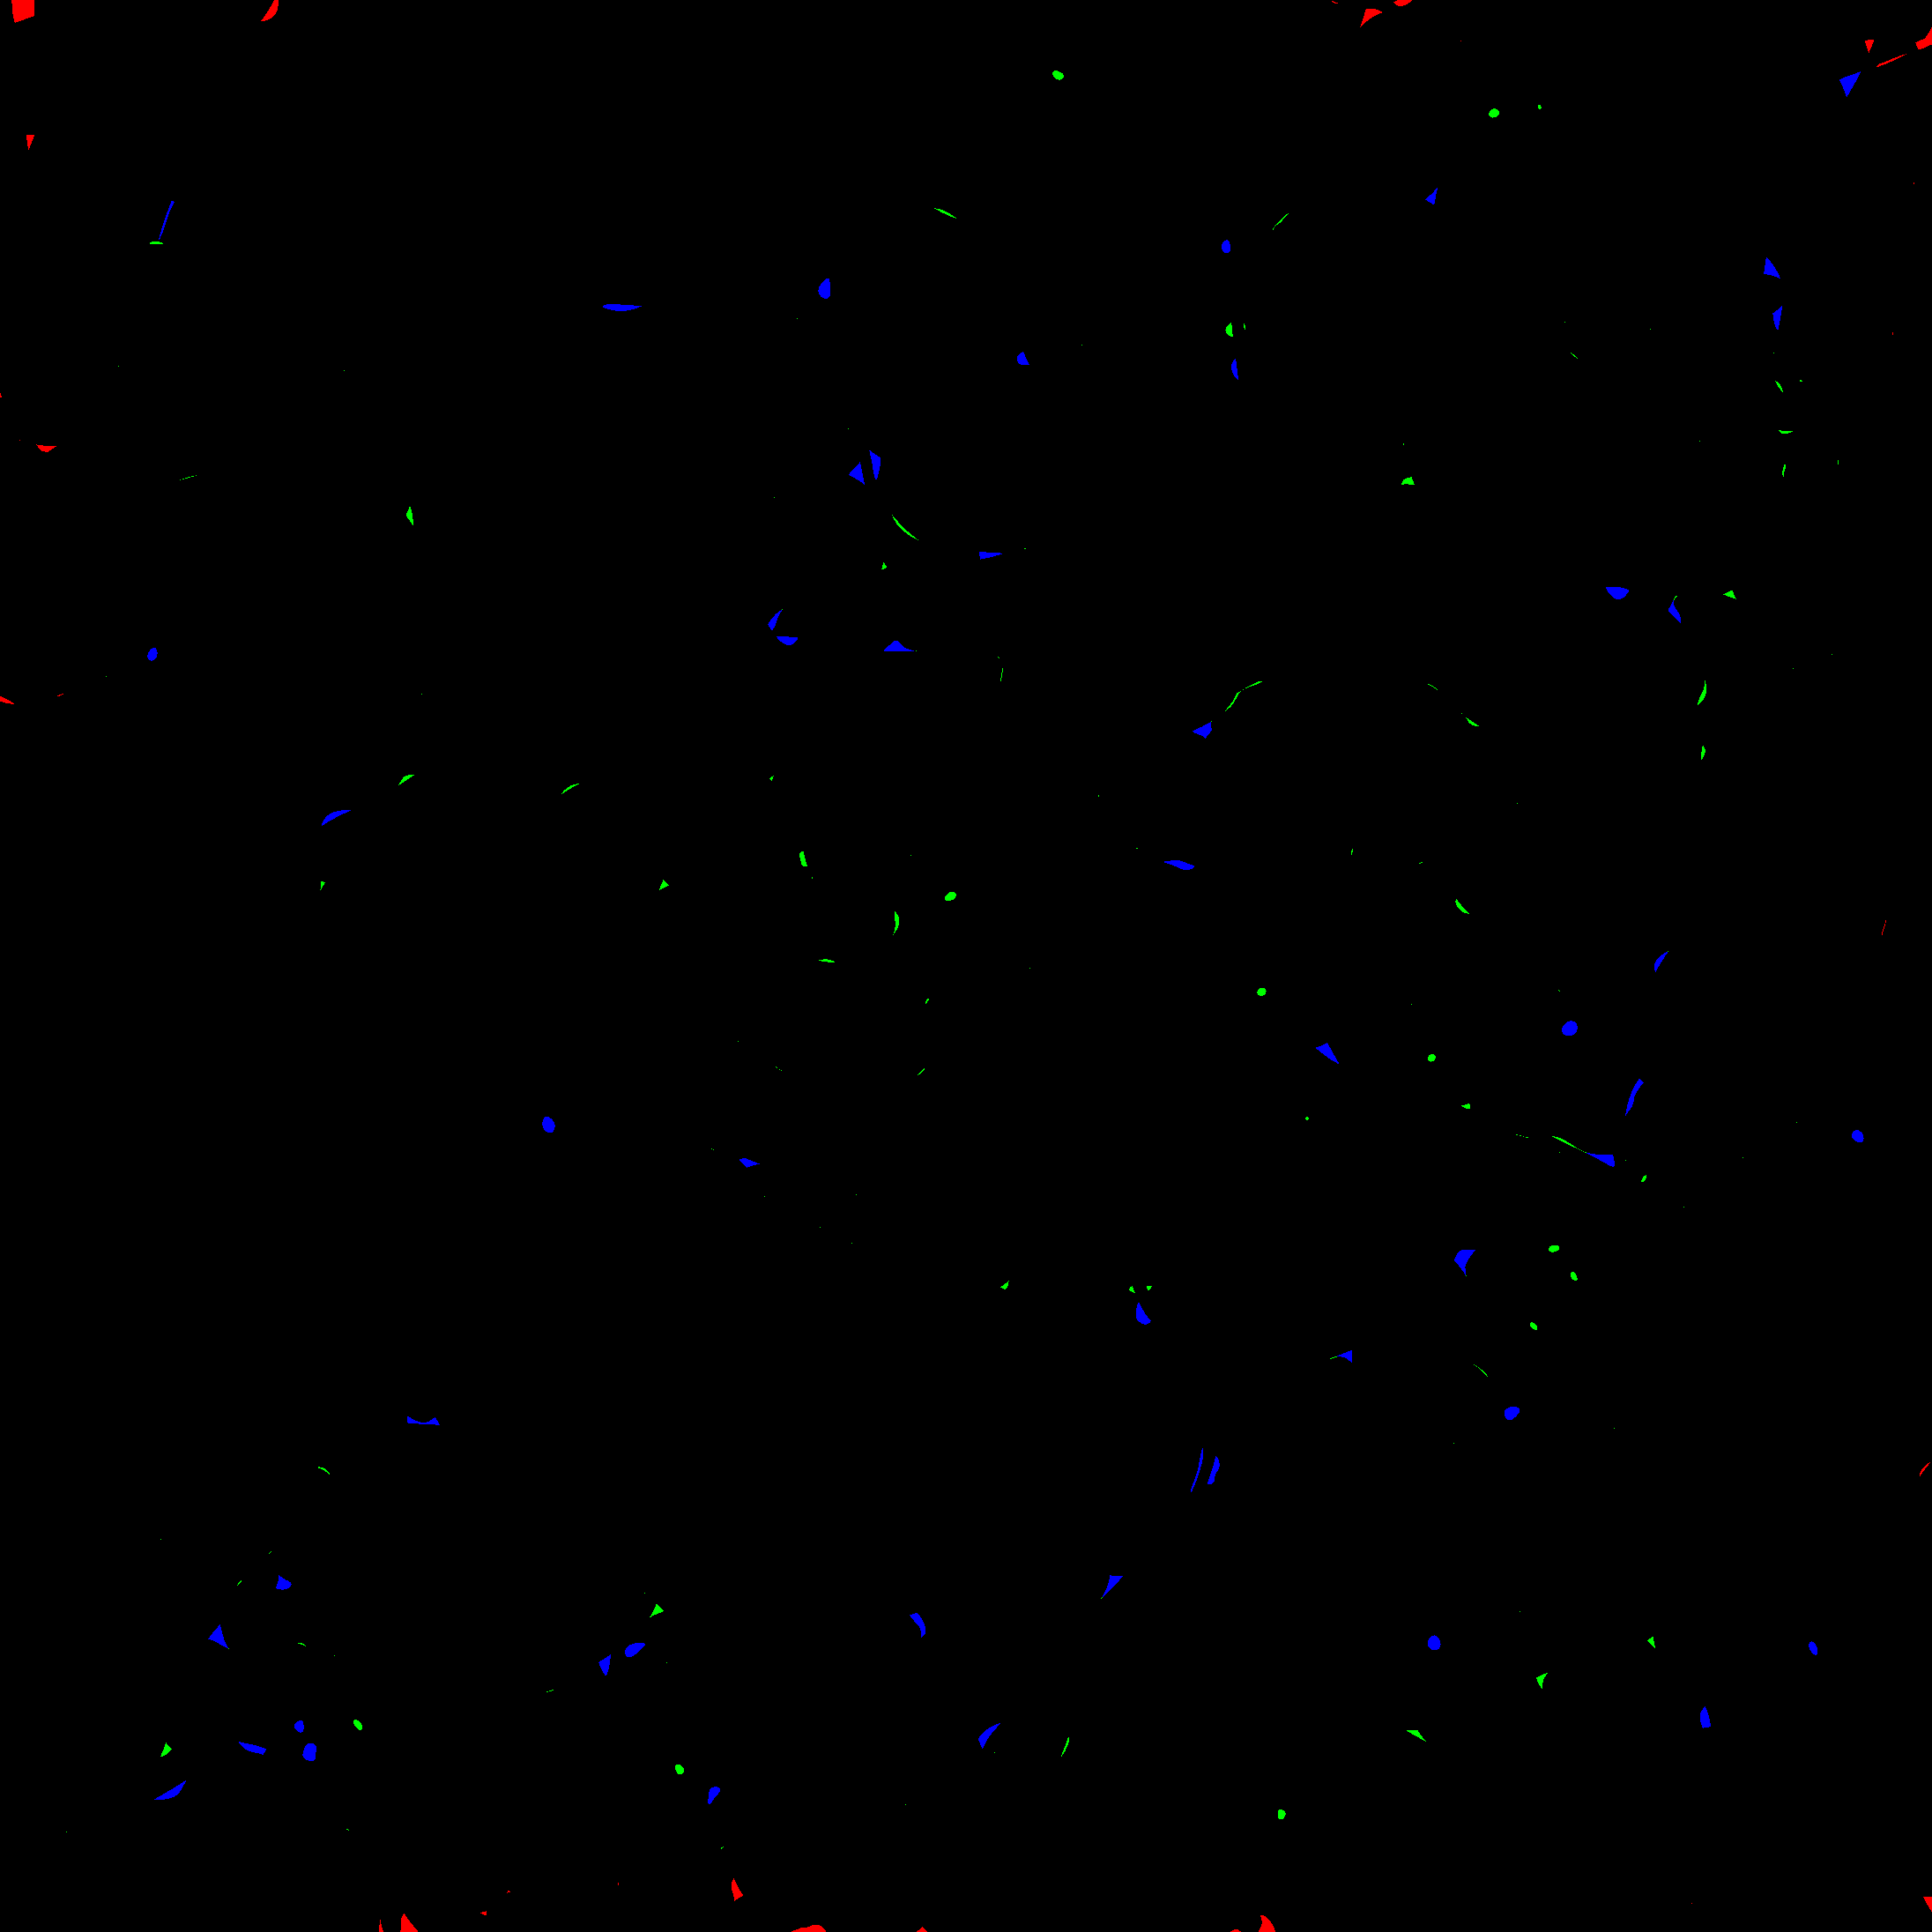

In [ ]:
orphan_palette = np.ndarray([4, 3], dtype=np.uint8)
orphan_palette[0] = [0, 0, 0]
orphan_palette[1] = [255, 0, 0]
orphan_palette[2] = [0, 255, 0]
orphan_palette[3] = [0, 0, 255]
display(Image.fromarray(orphan_palette[orphan_vis]))

In [ ]:
orphaned_large_ids = np.full(map_dim, 0)

# assign ids to large shapes
base = np.amax(tiles) + 1
for (idx, shape) in enumerate(large_shapes):
    for (x, y) in shape:
        orphaned_large_ids[x][y] = idx + base


# (small orphans are processed after id assignment)

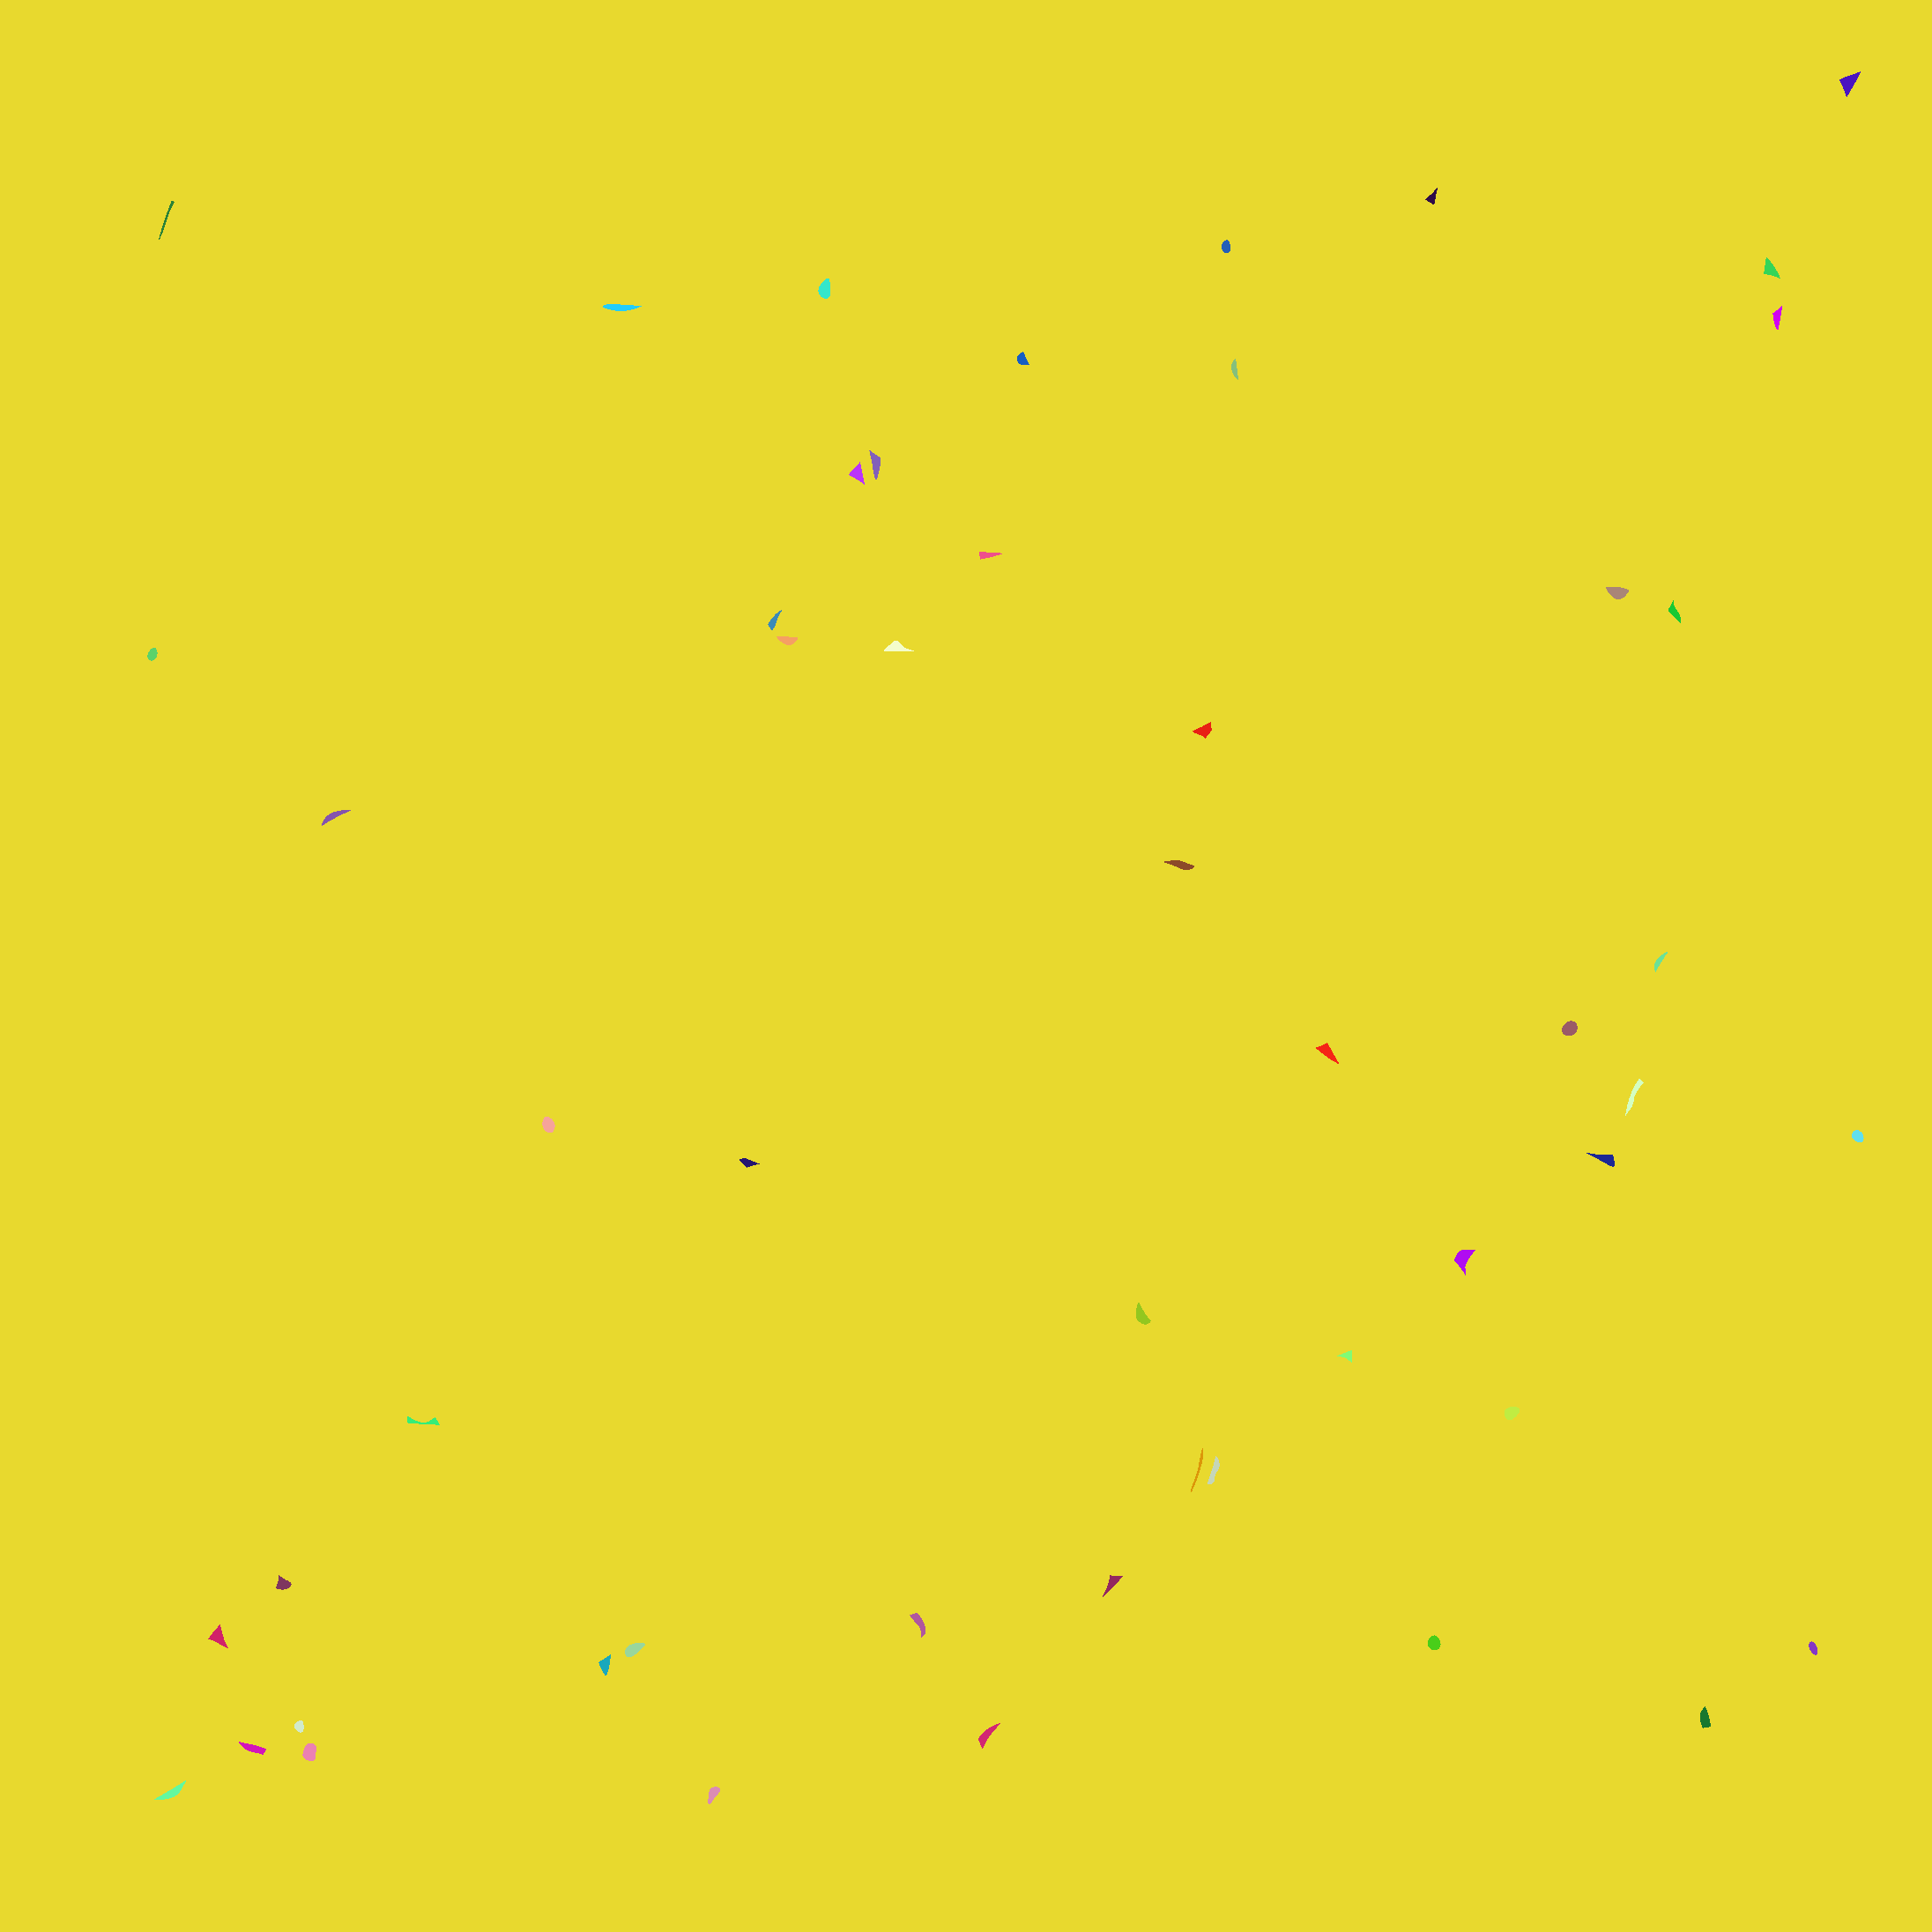

In [ ]:
orphan_id_palette = np.random.randint(0, 255, size=(np.amax(orphaned_large_ids) + 1, 3), dtype=np.uint8)
palette[0, :] = [0, 0, 0]
display(Image.fromarray(orphan_id_palette[orphaned_large_ids]))

### Split claimable and unclaimable

In [ ]:
claimable_tiles = np.multiply(tiles, or_many(*deed_masks.values()))
unclaimable_tiles = np.multiply(tiles, or_many(*unclaimable_masks.values()))

# layer large orphaned into unclaimable tiles
unclaimable_tiles = np.where(orphaned_large_ids > 0, orphaned_large_ids, unclaimable_tiles)

In [ ]:
#display(Image.fromarray(vis_padding_border(palette[claimable_tiles])))

In [ ]:
#palette = np.random.randint(0, 255, size=(unclaimable_tiles.max() + 1, 3), dtype=np.uint8)
#palette[-1, :] = [0, 0, 0]
#display(Image.fromarray(vis_padding_border(palette[unclaimable_tiles])))

### Remap IDs to contain no gaps

In [ ]:
gap_ct = 1
seen = {}
def remap_gap_ids(raw):
    if raw <= 0:
        return raw
    global gap_ct
    if raw not in seen:
        seen[raw] = gap_ct
        gap_ct += 1
    return seen[raw]
remap_fn = np.vectorize(remap_gap_ids)
local_claimable_ids = remap_fn(claimable_tiles)
local_claimable_id_num = len(seen)
print(f"Need {local_claimable_id_num} unique clamable reserved ids")
local_unclaimable_ids = remap_fn(unclaimable_tiles)
local_unclaimable_id_num = len(seen)
total_id_num = local_claimable_id_num + local_unclaimable_id_num
print(f"Need {local_unclaimable_id_num} unique unclaimable reserved ids")
print(f"Total reserved ids: {total_id_num}")

Need 5964 unique clamable reserved ids
Need 7027 unique unclaimable reserved ids
Total reserved ids: 12991


### Load ids

In [ ]:
with open(f"{ROOT_DIR}/alpha_world/plots/plot_ids_{chunk_name(chunk)}.json") as f:
    ids = json.load(f)
print(f"Loaded {len(ids)} reserved ids")

Loaded 15000 reserved ids


In [ ]:
### Assign ids to plots
if len(ids) < local_claimable_id_num:
    raise Exception("Need more IDs to be generated")
    
output = np.ndarray(regions.assignments.shape)
def map_id(raw):
    if raw == 0:
        return 0
    if raw == -1:
        return PADDING_MASK_ID
    return ids[raw-1]
map_id_fn = np.vectorize(map_id)

out_claimable_ids = map_id_fn(local_claimable_ids)
out_unclaimable_ids = map_id_fn(local_unclaimable_ids)


In [ ]:
# combine claimable and unclaimable ids
out_ids = np.where(np.logical_or(np.equal(out_claimable_ids, 0), np.equal(out_claimable_ids, PADDING_MASK_ID)), out_unclaimable_ids, out_claimable_ids)

# Combine with previous map
no_plot_map = np.equal(out_ids, 0)
out_ids = np.add(out_ids, no_plot_map * existing_plots).astype(np.uint64)

In [ ]:
# small orphans, merge into smallest connected appropriate plot

size_cache = {}
def plot_size_by_anchor(x, y):
    id = out_ids[x][y]
    if id in size_cache:
        return size_cache[id]
    if id == 0 or id == PADDING_MASK_ID:
        return 0
    to_explore = [(x,y)]
    seen = set()
    size = 0
    while len(to_explore) > 0:
        (x,y) = to_explore.pop()
        if (x, y) in seen:
            continue
        if x < 0 or x >= map_dim[0] or y < 0 or y >= map_dim[1]:
            continue
        seen.add((x,y))
        if out_ids[x][y] != id:
            continue
        size += 1
        to_explore.append((x-1, y))
        to_explore.append((x+1, y))
        to_explore.append((x, y-1))
        to_explore.append((x, y+1))
    size_cache[id] = size
    return size


# combine small shapes to the smallest connected plot, prefering any that region match
id_to_anchor = {}
for shape in small_shapes:
    connected_plots = set()
    connected_region_plots = set()
    region = regions.assignments[shape[0][0]][shape[0][1]]
    for (x, y) in shape:
        for pos in [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]:
            id = out_ids[pos[0]][pos[1]]
            id_to_anchor[id] = (pos[0], pos[1])
            connected_plots.add(id)
            if regions.assignments[pos[0]][pos[1]] == region:
                connected_region_plots.add(id)
    conn_plot_ls = list(connected_region_plots if len(connected_region_plots) > 0 else connected_plots)
    conn_plot_ls.sort(key=lambda id: plot_size_by_anchor(*(id_to_anchor[id])))
    conn_id = conn_plot_ls[0]
    for (x, y) in shape:
        out_ids[x][y] = conn_id



In [ ]:
# save full padding, store by row

index_builder = voxeloo.runs.IndexBuilder_U64(padding_dim[0]*padding_dim[1], 0)
for z in range(padding_dim[0]):
  for x in range(padding_dim[1]):
    index_builder.add(x + padding_dim[1] * z, out_ids[z][x])

index = index_builder.build()

In [ ]:
# write ids out

with open(f"{ROOT_DIR}/alpha_world/plots/plot_map_{chunk_name(chunk)}.txt", "w") as f:
    f.write(base64.encodebytes(index.dumps()).decode())

In [ ]:
#verify
json_index = voxeloo.runs.Index_U64()
with open(f"{ROOT_DIR}/alpha_world/plots/plot_map_{chunk_name(chunk)}.txt", "r") as f:
    json_index.loads(base64.decodebytes(f.read().encode()))
def getPlot(x, z):
    output_idx = index.get(x + padding_dim[1] * z)
    input_idx = out_ids[z-1][x-1]
    json_idx = json_index.get(x + padding_dim[1] * z)
    if (output_idx != input_idx):
        print("output/input mismatch " + str(output_idx) + " " + str(input_idx))
    if (output_idx != json_idx):
        print("json/output mismatch " + str(output_idx) + " " + str(input_idx))
    return index.get(x+z*padding_dim[1])
print(getPlot(100, 120))

2912127920628687


In [ ]:
#out_ids = np.where(np.logical_or(np.equal(out_claimable_ids, 0), np.equal(out_claimable_ids, PADDING_MASK_ID)), out_unclaimable_ids, out_claimable_ids)
#out_ids = np.where(np.equal(out_ids, 0), existing_plots, out_ids)

#display(Image.fromarray(np.equal(out_ids, PADDING_MASK_ID).astype(np.uint8) * 255))
#display(Image.fromarray(np.equal(existing_plots, PADDING_MASK_ID).astype(np.uint8) * 255))
#display(Image.fromarray(np.equal(no_plot_map, PADDING_MASK_ID).astype(np.uint8) * 255))
#display(Image.fromarray(np.add(out_ids, no_plot_map * existing_plots).astype(np.uint64)))
#display(Image.fromarray(np.logical_or(np.equal(out_ids, 0), np.equal(out_ids, PADDING_MASK_ID)).astype(np.uint8) * 255))
#display(Image.fromarray(np.equal(out_ids, PADDING_MASK_ID).astype(np.uint8) * 255))
#display(Image.fromarray(np.equal(out_claimable_ids, 0).astype(np.uint8) * 255))
#display(Image.fromarray(np.equal(out_unclaimable_ids, 0).astype(np.uint8) * 255))

# Parse metadata per-plot

In [ ]:
from collections import defaultdict
import math

plot_metadata = defaultdict(lambda: {
    "regionCount": defaultdict(lambda: 0),
    "box": [math.inf, math.inf, -math.inf, -math.inf],
    "playerClaimable": False
})

for x in range(0, map_dim[0]):
    for y in range(0, map_dim[1]):
        pos = (x - pos_offset[0], y - pos_offset[1])
        plot_id = out_ids[x][y]
        if plot_id == 0:
            continue
        if plot_id == PADDING_MASK_ID:
            continue
        region = id_to_region[regions.assignments[x][y]]
        plot_id_str = str(plot_id)
        plot_metadata[plot_id_str]["regionCount"][region] += 1
        plot_metadata[plot_id_str]["box"][0] = min(plot_metadata[plot_id_str]["box"][0], pos[0])
        plot_metadata[plot_id_str]["box"][1] = min(plot_metadata[plot_id_str]["box"][1], pos[1])
        plot_metadata[plot_id_str]["box"][2] = max(plot_metadata[plot_id_str]["box"][2], pos[0])
        plot_metadata[plot_id_str]["box"][3] = max(plot_metadata[plot_id_str]["box"][3], pos[1])
        plot_metadata[plot_id_str]["playerClaimable"] = region in deed_regions

#replace counts with max region
for plot_id in plot_metadata:
    region = max(plot_metadata[plot_id]["regionCount"], key=plot_metadata[plot_id]["regionCount"].get)
    plot_metadata[plot_id]["region"] = region
    del plot_metadata[plot_id]["regionCount"]

with open(f"{ROOT_DIR}/alpha_world/plots/plot_metadata_{chunk_name(chunk)}.json", "w") as f:
    f.write(json.dumps(plot_metadata))


In [ ]:
print("finished " + chunk_name(chunk))

finished 0_-1
